# NB08 — Predicción de evento severo con lead time real

**Pipeline:** PAC_v2 · Gold v1.2  
**Depende de:** NB01–NB07  
**Cohorte:** cohort_strict (8 pacientes, ≥10 noches in_strict)

### Objetivo
> **¿Con cuánto tiempo de anticipación puede el sistema predecir un EDO severo (C4/C5)?**

A diferencia de NB07 (que predice la severidad de un evento *ya en curso*), este análisis trabaja sobre  
**ventanas temporales continuas de 30 s** (escala S), sin condicionar a que haya un evento en progreso.  
Para cada ventana se predice si habrá un C4/C5 en los próximos Δt minutos,  
barriendo Δt ∈ {2, 5, 10, 15 min}.

### Motivación clínica
La estimulación eléctrica transcutánea requiere activarse **antes** del evento.  
La curva AUC vs Δt determina el horizonte óptimo de anticipación dado el ramp-up de la estimulación (~60–90 s).

## Diseño

### Unidad de análisis
Ventanas S de 30 s del sistema PAC (~840 por noche × 540 noches ≈ 450 K ventanas).

### Features — todas backward-looking desde t_start de la ventana
| Feature | Descripción |
|---|---|
| `state_s/m/l_enc` | Estado PAC actual en cada escala (entero) |
| `window_position` | Posición relativa en la noche (0–1) |
| `n_ev_5min` | Eventos en los últimos 5 min |
| `n_severe_5min` | C4/C5 en los últimos 5 min |
| `frac_severe_10min` | Fracción C4/C5 en los últimos 10 min |
| `morph_mean_5min` | Severidad morfológica media últimos 5 min (0=C1…4=C5) |
| `time_since_last_ev` | Segundos desde el último evento |
| `time_since_last_severe` | Segundos desde el último C4/C5 |
| `n_severe_sofar` | Conteo acumulado C4/C5 en la noche |
| `ci_sofar` | Coupling index acumulado hasta esta ventana |

### Targets multi-horizonte
Para cada ventana que termina en t_end:
- `y_2min`  → ¿C4/C5 con ts_start ∈ (t_end, t_end + 2 min)?
- `y_5min`  → ¿C4/C5 con ts_start ∈ (t_end, t_end + 5 min)?
- `y_10min` → ¿C4/C5 con ts_start ∈ (t_end, t_end + 10 min)?
- `y_15min` → ¿C4/C5 con ts_start ∈ (t_end, t_end + 15 min)?

### Validación
LOPO-CV estricto (leave-one-patient-out). Modelos: Logística baseline + LightGBM.

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd, matplotlib, re, time
from pathlib import Path
try:
    get_ipython()
except NameError:
    matplotlib.use('Agg')
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (roc_auc_score, average_precision_score,
                              roc_curve, precision_recall_curve)
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

try:
    import lightgbm as lgb
    LGBM_OK = True
except ImportError:
    LGBM_OK = False
    print("⚠ lightgbm no instalado — pip install lightgbm")

ROOT   = Path('..')
GOLD   = ROOT / 'gold'
FIGDIR = Path('figuras')
FIGDIR.mkdir(exist_ok=True)

def savefig(name):
    plt.tight_layout()
    plt.savefig(FIGDIR / name, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'  → {FIGDIR / name}')

plt.rcParams.update({'font.family':'DejaVu Sans','font.size':10,
    'axes.spines.top':False,'axes.spines.right':False,
    'figure.dpi':150,'figure.facecolor':'white','axes.facecolor':'#F8F8F8'})

DELTAS    = {'2min':120, '5min':300, '10min':600, '15min':900}
D_LABELS  = list(DELTAS.keys())
D_COLORS  = {'2min':'#e74c3c','5min':'#e67e22','10min':'#3498db','15min':'#2ecc71'}
MORPH_NUM = {'C1':0,'C2':1,'C3':2,'C4':3,'C5':4}
FEAT_COLS = ['state_s_enc','state_m_enc','state_l_enc','window_position',
             'n_ev_5min','n_severe_5min','frac_severe_10min','morph_mean_5min',
             'time_since_last_ev','time_since_last_severe','n_severe_sofar','ci_sofar']

def enc_lbl(s):
    if pd.isna(s): return np.nan
    m = re.search(r'(\d+)$', str(s))
    return float(m.group()) if m else np.nan

print(f"GOLD  : {GOLD.resolve()}")
print(f"LGBM  : {LGBM_OK}")
print("Setup OK ✓")

GOLD  : /Users/ri1965/Proyectos/PAC_v2/gold
LGBM  : True
Setup OK ✓


## Sección 1 — Preparación del dataset de ventanas

In [2]:
# Carga de parquets Gold
esm = pd.read_parquet(GOLD / 'event_states_multiscale.parquet')
nf  = pd.read_parquet(GOLD / 'night_features.parquet',
                       columns=['night_record_id','user_id','in_strict'])

# Cohort_strict: pacientes con ≥10 noches in_strict
pat_n         = nf[nf['in_strict']].groupby('user_id').size()
strict_pats   = pat_n[pat_n >= 10].index.tolist()
strict_nights = nf[nf['in_strict'] & nf['user_id'].isin(strict_pats)]['night_record_id'].tolist()
print(f"Pacientes cohort_strict : {sorted(strict_pats)}")
print(f"Noches in_strict        : {len(strict_nights)}")

# Eventos cohort_strict, con morph_num numérico
esm_s = esm[esm['night_record_id'].isin(strict_nights)].copy()
esm_s['morph_num'] = esm_s['morphotype_curve'].map(MORPH_NUM)
esm_s = esm_s.sort_values(['night_record_id','ts_start']).reset_index(drop=True)
print(f"Eventos cohort_strict   : {len(esm_s):,}")
print(f"Severos (C4/C5)         : {esm_s['is_severe'].sum():,} ({esm_s['is_severe'].mean()*100:.2f}%)")

# States por escala
states_raw = pd.read_parquet(GOLD / 'states.parquet')
states_raw = states_raw[states_raw['night_record_id'].isin(strict_nights)].copy()

sts_s = states_raw[states_raw['scale']=='s'].copy()
sts_m = states_raw[states_raw['scale']=='m'][['night_record_id','window_idx','state_label']].copy()
sts_l = states_raw[states_raw['scale']=='l'][['night_record_id','window_idx','state_label']].copy()
print(f"\nVentanas S: {len(sts_s):,}  M: {len(sts_m):,}  L: {len(sts_l):,}")

# Verificar duración de ventanas S
dur_s = sts_s['t_end_s'] - sts_s['t_start_s']
print(f"Duración ventana S (seg): median={dur_s.median():.0f}  p5={dur_s.quantile(.05):.0f}  p95={dur_s.quantile(.95):.0f}")

Pacientes cohort_strict : ['175', '240', '309', '314', '321', '336', '656', '683']
Noches in_strict        : 540
Eventos cohort_strict   : 83,672
Severos (C4/C5)         : 4,677 (5.59%)

Ventanas S: 454,407  M: 45,437  L: 7,586
Duración ventana S (seg): median=30  p5=30  p95=30


In [3]:
# A1: Dataset base — ventanas S con estado M/L asignado
# Estrategia: M-window que contiene una S-window = floor(t_start_s / 300)
#             L-window que contiene una S-window = floor(t_start_s / 1800)

sts_s = sts_s.copy()
sts_s['m_win_idx'] = (sts_s['t_start_s'] // 300).astype(int)
sts_s['l_win_idx'] = (sts_s['t_start_s'] // 1800).astype(int)

m_map = sts_m.rename(columns={'window_idx':'m_win_idx','state_label':'state_m_label'})
l_map = sts_l.rename(columns={'window_idx':'l_win_idx','state_label':'state_l_label'})

win_df = (sts_s
          .merge(m_map, on=['night_record_id','m_win_idx'], how='left')
          .merge(l_map, on=['night_record_id','l_win_idx'], how='left'))
win_df = win_df.rename(columns={'state_label':'state_s_label'})

# Encoding numérico de estados
win_df['state_s_enc'] = win_df['state_s_label'].apply(enc_lbl)
win_df['state_m_enc'] = win_df['state_m_label'].apply(enc_lbl)
win_df['state_l_enc'] = win_df['state_l_label'].apply(enc_lbl)

# Posición relativa en la noche (0 = inicio, 1 = fin)
night_max = win_df.groupby('night_record_id')['t_start_s'].transform('max').replace(0, np.nan)
win_df['window_position'] = (win_df['t_start_s'] / night_max).clip(0, 1)

# Solo ventanas con estado S válido, reset index para indexación posicional
win_df = win_df[win_df['state_s_enc'].notna()].reset_index(drop=True)

print(f"Ventanas S válidas      : {len(win_df):,}")
print(f"Con estado M asignado   : {win_df['state_m_enc'].notna().mean()*100:.1f}%")
print(f"Con estado L asignado   : {win_df['state_l_enc'].notna().mean()*100:.1f}%")
print(f"Noches cubiertas        : {win_df['night_record_id'].nunique()}")
print(f"Pacientes               : {win_df['user_id'].nunique()}")

Ventanas S válidas      : 452,955
Con estado M asignado   : 98.4%
Con estado L asignado   : 98.2%
Noches cubiertas        : 540
Pacientes               : 8


In [4]:
# A2: Features de contexto previo — vectorizado por noche (sin lookahead)
# Para cada ventana [t_start, t_end]: features de eventos con ts_start < t_start

print("Computando features de contexto (numpy vectorizado por noche)...")
t0 = time.time()

ROLL_COLS = ['n_ev_5min','n_severe_5min','frac_severe_10min','morph_mean_5min',
             'time_since_last_ev','time_since_last_severe','n_severe_sofar','ci_sofar']

roll_chunks = []
NS = np.int64(1_000_000_000)   # 1 s en nanosegundos

for nid, night_wins in win_df.groupby('night_record_id', sort=False):
    n_w  = len(night_wins)
    idx  = night_wins.index.values
    evs  = esm_s[esm_s['night_record_id'] == nid]

    if len(evs) == 0:
        blank = pd.DataFrame({
            'n_ev_5min':0,'n_severe_5min':0,'frac_severe_10min':0.0,
            'morph_mean_5min':np.nan,'time_since_last_ev':3600.0,
            'time_since_last_severe':3600.0,'n_severe_sofar':0,'ci_sofar':0.0
        }, index=idx)
        roll_chunks.append(blank)
        continue

    ev_t   = evs['ts_start'].values.astype('datetime64[ns]').astype('int64')  # → nanosegundos
    ev_sev = evs['is_severe'].values.astype(np.int8)       # (n_ev,)
    ev_mor = evs['morph_num'].fillna(-1.0).values          # -1 = sin dato

    win_t  = night_wins['t_start'].values.astype('datetime64[ns]').astype('int64')  # → nanosegundos

    # Matrices booleanas (n_win, n_ev) por broadcasting
    before = ev_t[None, :] < win_t[:, None]
    r5     = before & (ev_t[None, :] >= (win_t - 300*NS)[:, None])
    r10    = before & (ev_t[None, :] >= (win_t - 600*NS)[:, None])

    n_past    = before.sum(axis=1)
    n_ev5     = r5.sum(axis=1)
    n_sev5    = (r5  & (ev_sev[None, :] == 1)).sum(axis=1)
    n_ev10    = r10.sum(axis=1)
    n_sev10   = (r10 & (ev_sev[None, :] == 1)).sum(axis=1)
    n_sev_tot = (before & (ev_sev[None, :] == 1)).sum(axis=1)

    frac_sev10 = np.where(n_ev10  > 0, n_sev10  / n_ev10,  0.0)
    ci_sfr     = np.where(n_past  > 0, n_sev_tot / n_past, 0.0)

    # morph_mean_5min — ignorar -1 (NaN marker)
    mor_valid = (ev_mor != -1.0).astype(float)
    mor5_sum  = (r5 * np.where(ev_mor == -1, 0.0, ev_mor)[None, :]).sum(axis=1)
    mor5_n    = (r5 * mor_valid[None, :]).sum(axis=1)
    morph_m5  = np.where(mor5_n > 0, mor5_sum / mor5_n, np.nan)

    # time since last event / severe event (sentinel = 0 para max enmascarado)
    last_ev_t = np.where(before, ev_t[None, :], 0).max(axis=1)
    tl_ev     = np.where(n_past > 0, (win_t - last_ev_t) / NS, 3600.0)

    before_sv  = before & (ev_sev[None, :] == 1)
    last_sv_t  = np.where(before_sv, ev_t[None, :], 0).max(axis=1)
    n_sev_bf   = before_sv.sum(axis=1)
    tl_sv      = np.where(n_sev_bf > 0, (win_t - last_sv_t) / NS, 3600.0)

    chunk = pd.DataFrame({
        'n_ev_5min':           n_ev5.astype(float),
        'n_severe_5min':       n_sev5.astype(float),
        'frac_severe_10min':   frac_sev10,
        'morph_mean_5min':     morph_m5,
        'time_since_last_ev':  tl_ev,
        'time_since_last_severe': tl_sv,
        'n_severe_sofar':      n_sev_tot.astype(float),
        'ci_sofar':            ci_sfr,
    }, index=idx)
    roll_chunks.append(chunk)

roll_df = pd.concat(roll_chunks)
win_df  = win_df.join(roll_df)

print(f"  Completado en {time.time()-t0:.1f}s")
print(f"\nNaNs en features rolling:")
print(win_df[ROLL_COLS].isnull().sum().rename('n_nan').to_frame().T.to_string())

Computando features de contexto (numpy vectorizado por noche)...
  Completado en 4.9s

NaNs en features rolling:
       n_ev_5min  n_severe_5min  frac_severe_10min  morph_mean_5min  time_since_last_ev  time_since_last_severe  n_severe_sofar  ci_sofar
n_nan          0              0                  0           130138                   0                       0               0         0


In [5]:
# A3: Targets multi-horizonte — array numpy por delta (robusto a Copy-on-Write)
# Para cada ventana: ¿hay C4/C5 con ts_start en (t_end, t_end+Δt)?
# Construimos un array completo por delta y lo asignamos de una vez.

print("Computando targets multi-horizonte...")
t0 = time.time()
NS = int(1e9)

for dname, dsec in DELTAS.items():
    y_arr = np.zeros(len(win_df), dtype=np.int8)

    for nid, night_wins in win_df.groupby('night_record_id', sort=False):
        evs_sev = esm_s[(esm_s['night_record_id'] == nid) & (esm_s['is_severe'] == 1)]
        if len(evs_sev) == 0:
            continue
        ev_t  = np.sort(evs_sev['ts_start'].values.astype('datetime64[ns]').astype('int64'))
        t_end = night_wins['t_end'].values.astype('datetime64[ns]').astype('int64')
        t_fut = t_end + dsec * NS
        lo = np.searchsorted(ev_t, t_end, side='right')
        hi = np.searchsorted(ev_t, t_fut, side='right')
        y_arr[night_wins.index.values] = (hi > lo).astype(np.int8)

    win_df[f'y_{dname}'] = y_arr

print(f"  Completado en {time.time()-t0:.1f}s")
print("\nPrevalencia por horizonte (% ventanas con C4/C5 en horizonte):")
for dname in DELTAS:
    col  = f'y_{dname}'
    prev = win_df[col].mean() * 100
    print(f"  {dname:6s}: {win_df[col].sum():6,} positivos / {len(win_df):,} = {prev:.2f}%")

# Verificación: confirmar que hay positivos en cada horizonte
print("\nVerificación por paciente (horizonte 5min — debe haber positivos en todos):")
check = win_df.groupby('user_id')['y_5min'].sum()
print(check.to_string())
assert (check > 0).all(), "⚠ Algún paciente no tiene positivos en y_5min"
print("✓ Todos los pacientes tienen ventanas positivas")

Computando targets multi-horizonte...
  Completado en 13.1s

Prevalencia por horizonte (% ventanas con C4/C5 en horizonte):
  2min  : 16,951 positivos / 452,955 = 3.74%
  5min  : 36,438 positivos / 452,955 = 8.04%
  10min : 62,853 positivos / 452,955 = 13.88%
  15min : 85,583 positivos / 452,955 = 18.89%

Verificación por paciente (horizonte 5min — debe haber positivos en todos):
user_id
175    6836
240    2368
309    2596
314     119
321    3898
336    8275
656    7165
683    5181
✓ Todos los pacientes tienen ventanas positivas


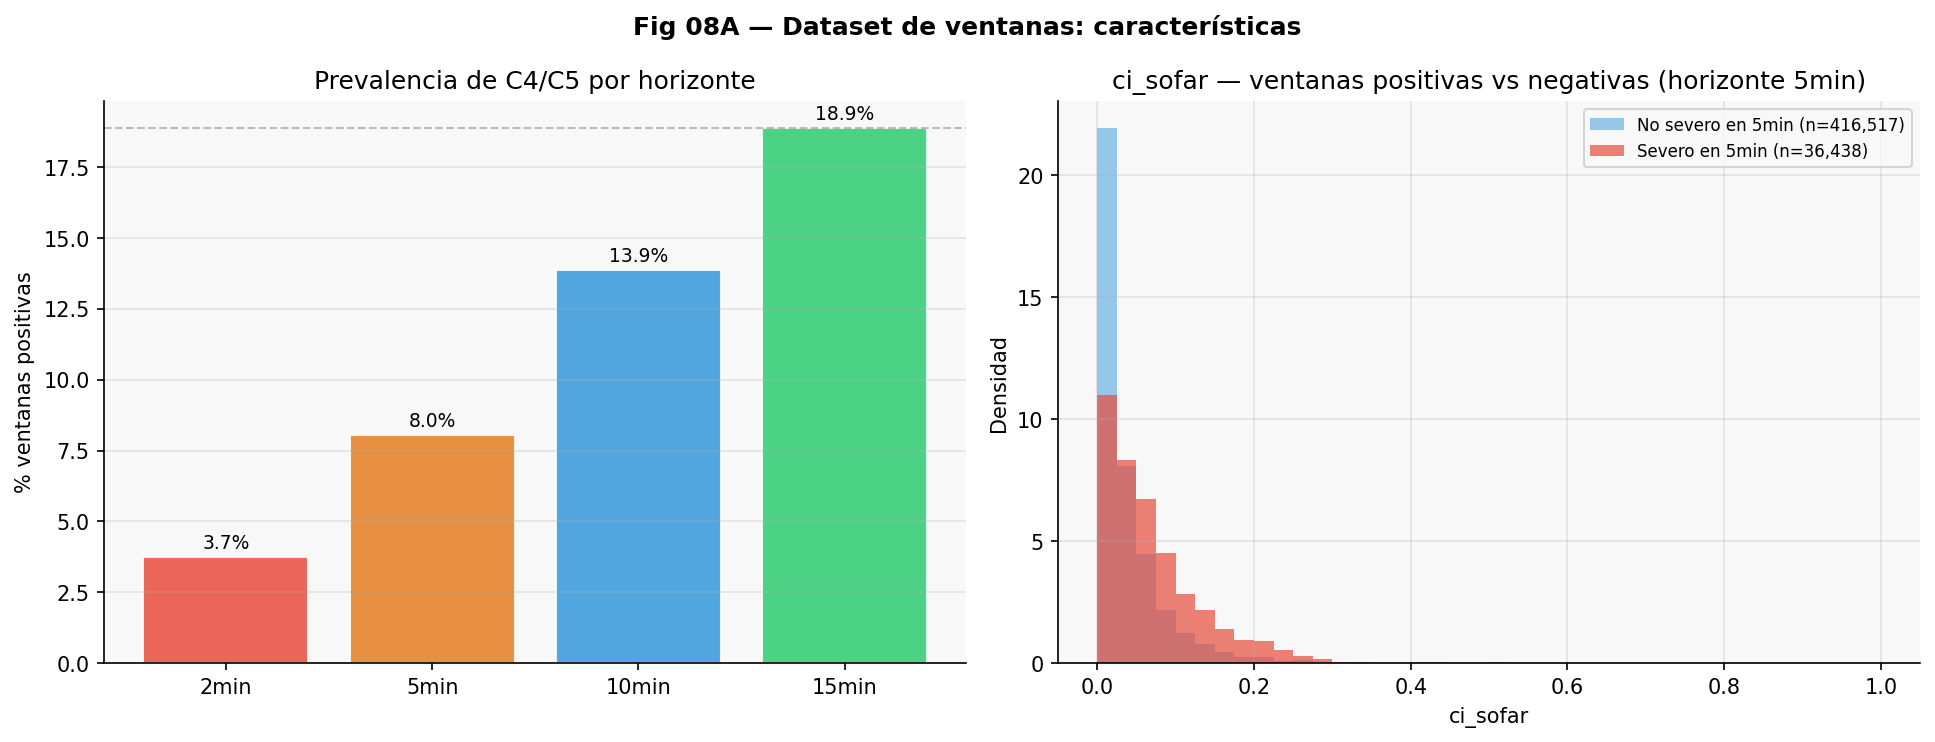

  → figuras/08A_exploratorio.png

Prevalencia por paciente (horizonte 5min):
         n_total  n_pos  prevalence_pct
user_id                                
175        21271   6836            32.1
240        19205   2368            12.3
309        53138   2596             4.9
314         7561    119             1.6
321        80438   3898             4.8
336       115701   8275             7.2
656        90886   7165             7.9
683        64755   5181             8.0


In [6]:
# Análisis exploratorio — prevalencia por horizonte y por paciente

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Fig 08A — Dataset de ventanas: características', fontsize=12, fontweight='bold')

# Panel izq: prevalencia por horizonte
ax = axes[0]
prevs = [win_df[f'y_{d}'].mean()*100 for d in D_LABELS]
bars  = ax.bar(D_LABELS, prevs, color=[D_COLORS[d] for d in D_LABELS], alpha=0.85, edgecolor='white')
ax.set_ylabel('% ventanas positivas')
ax.set_title('Prevalencia de C4/C5 por horizonte')
ax.axhline(win_df['y_15min'].mean()*100, color='gray', ls='--', lw=1, alpha=0.5, label='baseline 15min')
for bar, v in zip(bars, prevs):
    ax.text(bar.get_x()+bar.get_width()/2, v+0.3, f'{v:.1f}%', ha='center', fontsize=9)
ax.grid(axis='y', alpha=0.3)

# Panel der: distribución de features clave (y_5min como referencia)
ax = axes[1]
feat_ref = 'ci_sofar'
v0 = win_df[win_df['y_5min']==0][feat_ref].dropna()
v1 = win_df[win_df['y_5min']==1][feat_ref].dropna()
ax.hist(v0, bins=40, alpha=0.5, color='#3498db', density=True, label=f'No severo en 5min (n={len(v0):,})')
ax.hist(v1, bins=40, alpha=0.7, color='#e74c3c', density=True, label=f'Severo en 5min (n={len(v1):,})')
ax.set_xlabel(feat_ref); ax.set_ylabel('Densidad')
ax.set_title(f'{feat_ref} — ventanas positivas vs negativas (horizonte 5min)')
ax.legend(fontsize=8); ax.grid(alpha=0.3)
savefig('08A_exploratorio.png')

# Prevalencia por paciente y horizonte
print("\nPrevalencia por paciente (horizonte 5min):")
pp = win_df.groupby('user_id')['y_5min'].agg(['sum','count','mean'])
pp.columns = ['n_pos','n_total','prevalence']
pp['prevalence_pct'] = (pp['prevalence']*100).round(1)
print(pp[['n_total','n_pos','prevalence_pct']].to_string())

## Sección 2 — Modelos predictivos LOPO-CV

In [7]:
# Preparación del dataset para modelos
# Imputar NaN con mediana por feature

# Verificar targets antes de crear df_model
print("Targets en win_df antes de crear df_model:")
for d in D_LABELS:
    print(f"  y_{d}: {win_df[f'y_{d}'].sum():,} positivos ({win_df[f'y_{d}'].mean()*100:.2f}%)")

df_model = win_df[FEAT_COLS + [f'y_{d}' for d in D_LABELS] + ['user_id','night_record_id']].copy()
for col in FEAT_COLS:
    if df_model[col].isnull().any():
        df_model[col] = df_model[col].fillna(df_model[col].median())

PATIENTS = sorted(df_model['user_id'].unique())
print(f"Dataset modelo: {len(df_model):,} ventanas  |  {len(PATIENTS)} pacientes")
print(f"Features: {len(FEAT_COLS)}")
print(f"  {FEAT_COLS}")
print(f"\nNaNs post-imputación: {df_model[FEAT_COLS].isnull().sum().sum()}")
print(f"\nDistribución por paciente:")
print(df_model.groupby('user_id').size().rename('n_ventanas').to_string())

Targets en win_df antes de crear df_model:
  y_2min: 16,951 positivos (3.74%)
  y_5min: 36,438 positivos (8.04%)
  y_10min: 62,853 positivos (13.88%)
  y_15min: 85,583 positivos (18.89%)
Dataset modelo: 452,955 ventanas  |  8 pacientes
Features: 12
  ['state_s_enc', 'state_m_enc', 'state_l_enc', 'window_position', 'n_ev_5min', 'n_severe_5min', 'frac_severe_10min', 'morph_mean_5min', 'time_since_last_ev', 'time_since_last_severe', 'n_severe_sofar', 'ci_sofar']

NaNs post-imputación: 0

Distribución por paciente:
user_id
175     21271
240     19205
309     53138
314      7561
321     80438
336    115701
656     90886
683     64755


In [8]:
# B1: LOPO-CV — Logística baseline (todos los horizontes)

print("LOPO-CV Logística (todos los horizontes)...")
lr_results = {d: {'aucs':[], 'aps':[], 'probs':[], 'true':[]} for d in D_LABELS}

for pat_out in PATIENTS:
    tr_mask = df_model['user_id'] != pat_out
    te_mask = df_model['user_id'] == pat_out
    X_tr = df_model.loc[tr_mask, FEAT_COLS].values
    X_te = df_model.loc[te_mask, FEAT_COLS].values

    for dname in D_LABELS:
        y_tr = df_model.loc[tr_mask, f'y_{dname}'].values
        y_te = df_model.loc[te_mask, f'y_{dname}'].values
        pipe = Pipeline([
            ('imp', SimpleImputer(strategy='median')),
            ('sc',  StandardScaler()),
            ('clf', LogisticRegression(C=1.0, class_weight='balanced',
                                       max_iter=1000, random_state=42, n_jobs=-1))
        ])
        pipe.fit(X_tr, y_tr)
        prob = pipe.predict_proba(X_te)[:, 1]

        if 0 < y_te.sum() < len(y_te):
            lr_results[dname]['aucs'].append(roc_auc_score(y_te, prob))
            lr_results[dname]['aps'].append(average_precision_score(y_te, prob))
        lr_results[dname]['probs'].extend(prob.tolist())
        lr_results[dname]['true'].extend(y_te.tolist())

print("\nLogística — AUC global LOPO-CV por horizonte:")
for dname in D_LABELS:
    all_t = np.array(lr_results[dname]['true'])
    all_p = np.array(lr_results[dname]['probs'])
    auc_g = roc_auc_score(all_t, all_p)
    ap_g  = average_precision_score(all_t, all_p)
    base  = all_t.mean()
    print(f"  {dname:6s}: AUC={auc_g:.3f}  AP={ap_g:.3f}  mejora={ap_g/base:.1f}×  base={base:.3f}")
    lr_results[dname]['auc_global'] = auc_g
    lr_results[dname]['ap_global']  = ap_g

LOPO-CV Logística (todos los horizontes)...

Logística — AUC global LOPO-CV por horizonte:
  2min  : AUC=0.789  AP=0.172  mejora=4.6×  base=0.037
  5min  : AUC=0.774  AP=0.265  mejora=3.3×  base=0.080
  10min : AUC=0.760  AP=0.350  mejora=2.5×  base=0.139
  15min : AUC=0.750  AP=0.416  mejora=2.2×  base=0.189


In [9]:
# B2: LOPO-CV — LightGBM (todos los horizontes)

if not LGBM_OK:
    print("⚠ LightGBM no disponible — instalar con: pip install lightgbm")
else:
    print("LOPO-CV LightGBM (todos los horizontes)...")
    t0 = time.time()
    lgbm_params = dict(n_estimators=300, max_depth=6, learning_rate=0.05,
                       num_leaves=31, subsample=0.8, colsample_bytree=0.8,
                       class_weight='balanced', random_state=42, n_jobs=-1, verbose=-1)
    lgbm_results = {d: {'aucs':[], 'aps':[], 'probs':[], 'true':[]} for d in D_LABELS}

    for pat_out in PATIENTS:
        tr_mask = df_model['user_id'] != pat_out
        te_mask = df_model['user_id'] == pat_out
        X_tr = df_model.loc[tr_mask, FEAT_COLS].values
        X_te = df_model.loc[te_mask, FEAT_COLS].values

        for dname in D_LABELS:
            y_tr = df_model.loc[tr_mask, f'y_{dname}'].values
            y_te = df_model.loc[te_mask, f'y_{dname}'].values
            imp  = SimpleImputer(strategy='median')
            X_tr_imp = imp.fit_transform(X_tr)
            X_te_imp = imp.transform(X_te)
            clf  = lgb.LGBMClassifier(**lgbm_params)
            clf.fit(X_tr_imp, y_tr)
            prob = clf.predict_proba(X_te_imp)[:, 1]

            if 0 < y_te.sum() < len(y_te):
                lgbm_results[dname]['aucs'].append(roc_auc_score(y_te, prob))
                lgbm_results[dname]['aps'].append(average_precision_score(y_te, prob))
            lgbm_results[dname]['probs'].extend(prob.tolist())
            lgbm_results[dname]['true'].extend(y_te.tolist())

    print(f"  Completado en {time.time()-t0:.1f}s")
    print("\nLightGBM — AUC global LOPO-CV por horizonte:")
    for dname in D_LABELS:
        all_t = np.array(lgbm_results[dname]['true'])
        all_p = np.array(lgbm_results[dname]['probs'])
        auc_g = roc_auc_score(all_t, all_p)
        ap_g  = average_precision_score(all_t, all_p)
        base  = all_t.mean()
        print(f"  {dname:6s}: AUC={auc_g:.3f}  AP={ap_g:.3f}  mejora={ap_g/base:.1f}×  base={base:.3f}")
        lgbm_results[dname]['auc_global'] = auc_g
        lgbm_results[dname]['ap_global']  = ap_g

LOPO-CV LightGBM (todos los horizontes)...
  Completado en 64.1s

LightGBM — AUC global LOPO-CV por horizonte:
  2min  : AUC=0.838  AP=0.203  mejora=5.4×  base=0.037
  5min  : AUC=0.821  AP=0.326  mejora=4.1×  base=0.080
  10min : AUC=0.783  AP=0.396  mejora=2.9×  base=0.139
  15min : AUC=0.763  AP=0.449  mejora=2.4×  base=0.189


"# Panel der: tabla resumen\nax3 = fig.add_subplot(1, 3, 3); ax3.axis('off')\nrows = [['Horizonte','AUC-LR','AUC-LGBM','AP-LGBM','Base%']]\nfor dname in D_LABELS:\n    base = np.array(best_res[dname]['true']).mean()*100\n    auc_lr = lr_results[dname]['auc_global']\n    auc_lg = lgbm_results[dname]['auc_global'] if LGBM_OK else float('nan')\n    ap_lg  = lgbm_results[dname]['ap_global']  if LGBM_OK else float('nan')\n    rows.append([dname, f'{auc_lr:.3f}', f'{auc_lg:.3f}', f'{ap_lg:.3f}', f'{base:.1f}%'])\ntbl = ax3.table(cellText=rows[1:], colLabels=rows[0], loc='center', cellLoc='center')\ntbl.auto_set_font_size(False); tbl.set_fontsize(9)\nfor (r,c), cell in tbl.get_celld().items():\n    if r==0: cell.set_facecolor('#2E75B6'); cell.set_text_props(color='w',fontweight='bold')\n    elif r%2==0: cell.set_facecolor('#F0F7FF')\n    cell.set_edgecolor('#CCCCCC')\nax3.set_title('Resumen métricas', fontsize=10, fontweight='bold', pad=120)\nsavefig('08B_auc_vs_lead_time.png')"

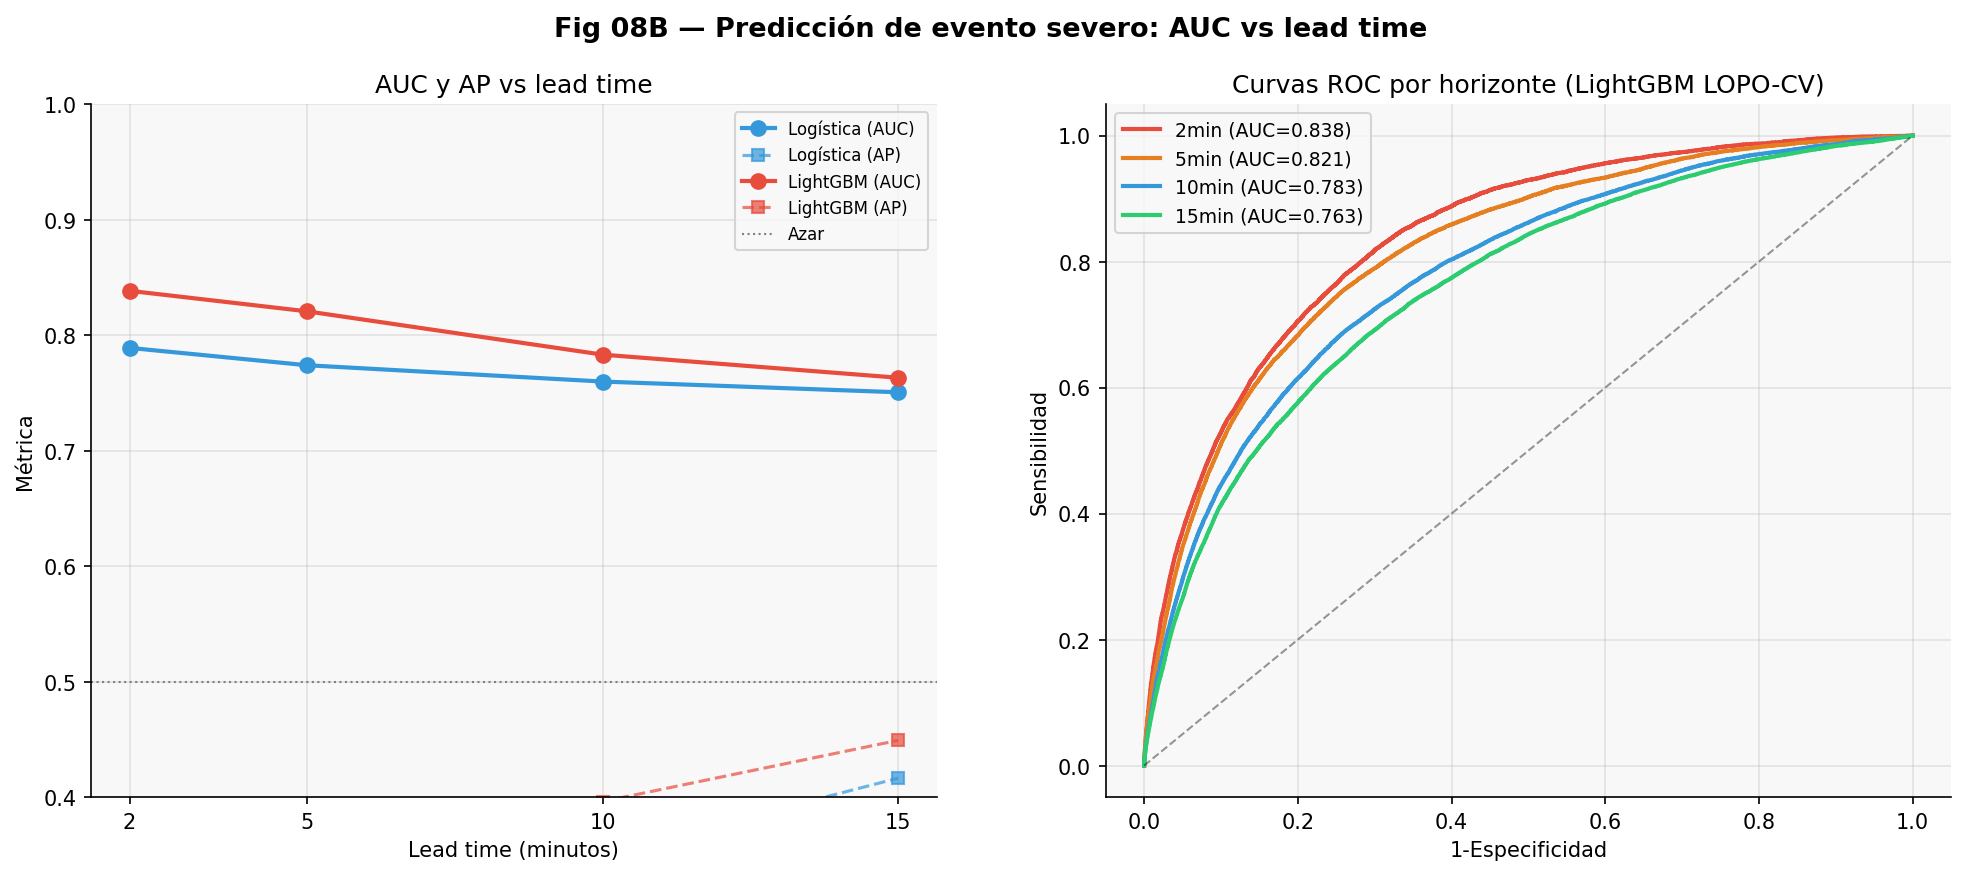

In [16]:
# B3: FIGURA CLAVE — AUC vs lead time + curvas ROC por horizonte

fig = plt.figure(figsize=(16, 6))
fig.suptitle('Fig 08B — Predicción de evento severo: AUC vs lead time', fontsize=13, fontweight='bold')

# Panel izq: AUC vs Δt
ax1 = fig.add_subplot(1, 2, 1)
delta_vals = [int(v/60) for v in DELTAS.values()]  # en minutos
lr_aucs   = [lr_results[d]['auc_global']   for d in D_LABELS]
lr_aps    = [lr_results[d]['ap_global']    for d in D_LABELS]
ax1.plot(delta_vals, lr_aucs, 'o-', color='#3498db', lw=2, ms=7, label='Logística (AUC)')
ax1.plot(delta_vals, lr_aps,  's--', color='#3498db', lw=1.5, ms=6, alpha=0.7, label='Logística (AP)')
if LGBM_OK:
    lgbm_aucs = [lgbm_results[d]['auc_global'] for d in D_LABELS]
    lgbm_aps  = [lgbm_results[d]['ap_global']  for d in D_LABELS]
    ax1.plot(delta_vals, lgbm_aucs, 'o-', color='#e74c3c', lw=2, ms=7, label='LightGBM (AUC)')
    ax1.plot(delta_vals, lgbm_aps,  's--', color='#e74c3c', lw=1.5, ms=6, alpha=0.7, label='LightGBM (AP)')
ax1.axhline(0.5, color='gray', ls=':', lw=1, label='Azar')
ax1.set_xlabel('Lead time (minutos)'); ax1.set_ylabel('Métrica')
ax1.set_title('AUC y AP vs lead time'); ax1.legend(fontsize=8)
ax1.set_xticks(delta_vals); ax1.grid(alpha=0.3); ax1.set_ylim(0.4, 1.0)

# Panel central: curvas ROC por horizonte (mejor modelo)
ax2 = fig.add_subplot(1, 2, 2)
best_res = lgbm_results if LGBM_OK else lr_results
for dname in D_LABELS:
    all_t = np.array(best_res[dname]['true'])
    all_p = np.array(best_res[dname]['probs'])
    fpr, tpr, _ = roc_curve(all_t, all_p)
    ax2.plot(fpr, tpr, color=D_COLORS[dname], lw=2,
             label=f'{dname} (AUC={best_res[dname]["auc_global"]:.3f})')
ax2.plot([0,1],[0,1],'k--',lw=1,alpha=0.4)
ax2.set_xlabel('1-Especificidad'); ax2.set_ylabel('Sensibilidad')
ax2.set_title('Curvas ROC por horizonte (LightGBM LOPO-CV)')
ax2.legend(fontsize=9); ax2.grid(alpha=0.3)

'''# Panel der: tabla resumen
ax3 = fig.add_subplot(1, 3, 3); ax3.axis('off')
rows = [['Horizonte','AUC-LR','AUC-LGBM','AP-LGBM','Base%']]
for dname in D_LABELS:
    base = np.array(best_res[dname]['true']).mean()*100
    auc_lr = lr_results[dname]['auc_global']
    auc_lg = lgbm_results[dname]['auc_global'] if LGBM_OK else float('nan')
    ap_lg  = lgbm_results[dname]['ap_global']  if LGBM_OK else float('nan')
    rows.append([dname, f'{auc_lr:.3f}', f'{auc_lg:.3f}', f'{ap_lg:.3f}', f'{base:.1f}%'])
tbl = ax3.table(cellText=rows[1:], colLabels=rows[0], loc='center', cellLoc='center')
tbl.auto_set_font_size(False); tbl.set_fontsize(9)
for (r,c), cell in tbl.get_celld().items():
    if r==0: cell.set_facecolor('#2E75B6'); cell.set_text_props(color='w',fontweight='bold')
    elif r%2==0: cell.set_facecolor('#F0F7FF')
    cell.set_edgecolor('#CCCCCC')
ax3.set_title('Resumen métricas', fontsize=10, fontweight='bold', pad=120)
savefig('08B_auc_vs_lead_time.png')'''

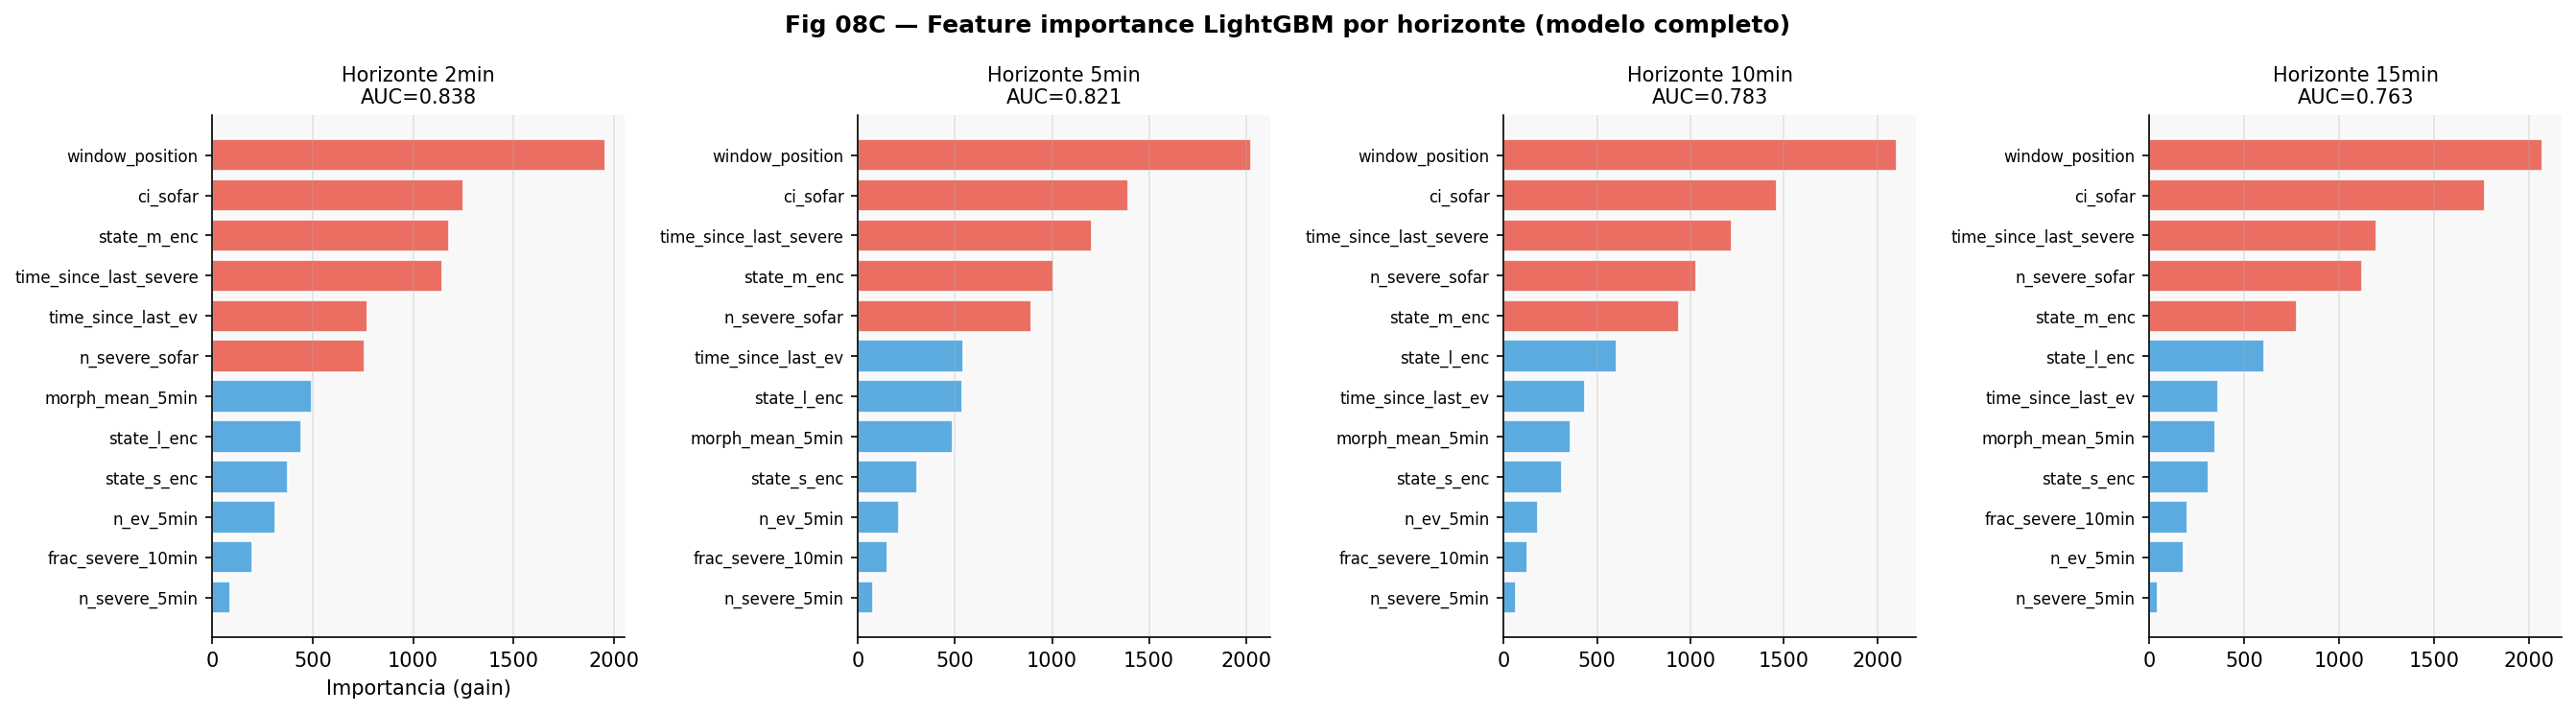

  → figuras/08C_feature_importance_por_horizonte.png


In [11]:
# B4: Feature importance LightGBM por horizonte

if not LGBM_OK:
    print("⚠ LightGBM no disponible")
else:
    fig, axes = plt.subplots(1, len(D_LABELS), figsize=(18, 5))
    fig.suptitle('Fig 08C — Feature importance LightGBM por horizonte (modelo completo)',
                 fontsize=12, fontweight='bold')
    for ax, dname in zip(axes, D_LABELS):
        clf_full = lgb.LGBMClassifier(n_estimators=300, max_depth=6, learning_rate=0.05,
                                       num_leaves=31, class_weight='balanced',
                                       random_state=42, n_jobs=-1, verbose=-1)
        clf_full.fit(df_model[FEAT_COLS].values, df_model[f'y_{dname}'].values)
        fi = pd.Series(clf_full.feature_importances_, index=FEAT_COLS).sort_values()
        colors = ['#e74c3c' if v > fi.mean() else '#3498db' for v in fi.values]
        ax.barh(range(len(fi)), fi.values, color=colors, alpha=0.8, edgecolor='white')
        ax.set_yticks(range(len(fi))); ax.set_yticklabels(fi.index, fontsize=8)
        ax.set_title(f'Horizonte {dname}\nAUC={lgbm_results[dname]["auc_global"]:.3f}', fontsize=10)
        ax.grid(axis='x', alpha=0.3)
        if dname == D_LABELS[0]: ax.set_xlabel('Importancia (gain)')
    savefig('08C_feature_importance_por_horizonte.png')

## Sección 3 — Análisis operacional

Umbral Youden por horizonte:
  2min  : thr=0.393  Sens=0.819  Spec=0.700  Prec~0.096
  5min  : thr=0.459  Sens=0.755  Spec=0.741  Prec~0.203
  10min : thr=0.473  Sens=0.690  Spec=0.738  Prec~0.298
  15min : thr=0.465  Sens=0.683  Spec=0.710  Prec~0.354


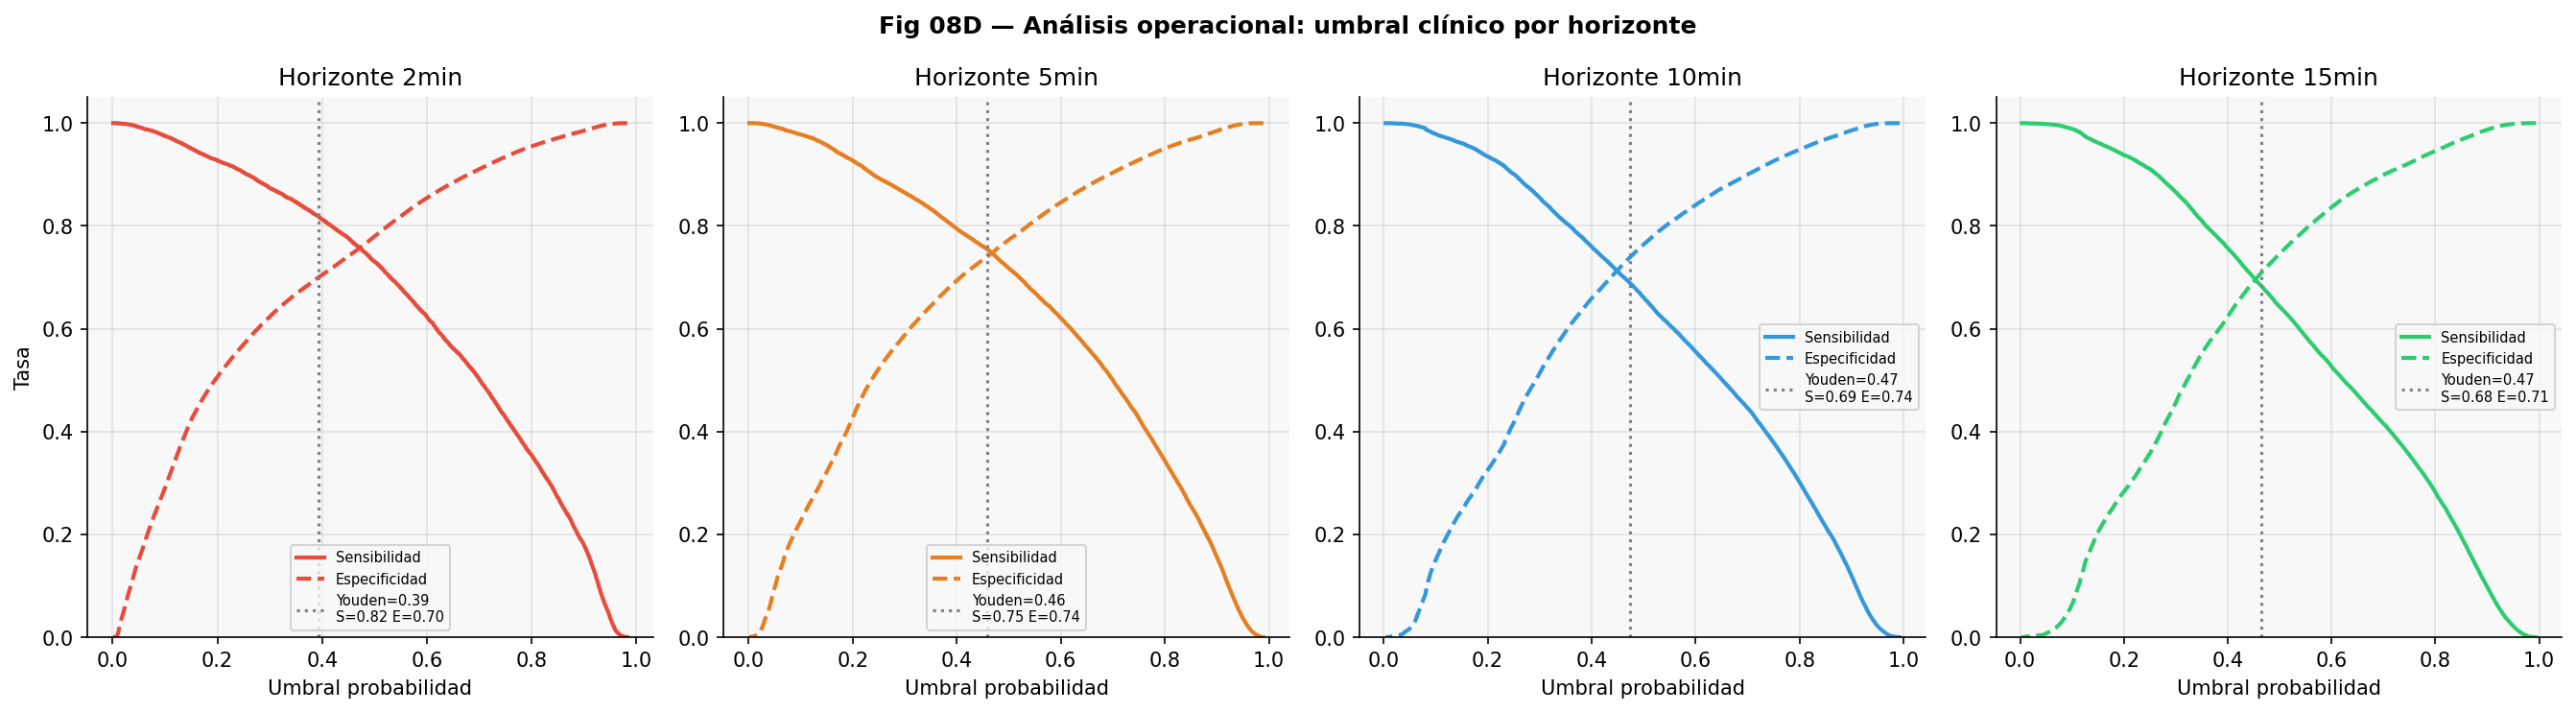

  → figuras/08D_umbral_operacional.png


In [12]:
# C1: Curvas operacionales — Sensibilidad vs Especificidad por horizonte

best_res = lgbm_results if LGBM_OK else lr_results
fig, axes = plt.subplots(1, len(D_LABELS), figsize=(18, 5))
fig.suptitle('Fig 08D — Análisis operacional: umbral clínico por horizonte',
             fontsize=12, fontweight='bold')

print("Umbral Youden por horizonte:")
youden_thrs = {}
for ax, dname in zip(axes, D_LABELS):
    all_t = np.array(best_res[dname]['true'])
    all_p = np.array(best_res[dname]['probs'])
    fpr, tpr, thr = roc_curve(all_t, all_p)
    J       = tpr[1:] + (1 - fpr[1:]) - 1
    opt_idx = np.argmax(J)
    opt_thr = thr[1:][opt_idx]
    opt_sens= tpr[1:][opt_idx]
    opt_spec= 1 - fpr[1:][opt_idx]
    youden_thrs[dname] = opt_thr
    print(f"  {dname:6s}: thr={opt_thr:.3f}  Sens={opt_sens:.3f}  Spec={opt_spec:.3f}  "
          f"Prec~{(opt_sens*all_t.mean()/((opt_sens*all_t.mean())+(1-opt_spec)*(1-all_t.mean()))):.3f}")

    ax.plot(thr[1:], tpr[1:], color=D_COLORS[dname], lw=2, label='Sensibilidad')
    ax.plot(thr[1:], 1-fpr[1:], color=D_COLORS[dname], lw=2, ls='--', label='Especificidad')
    ax.axvline(opt_thr, color='gray', ls=':', lw=1.5,
               label=f'Youden={opt_thr:.2f}\nS={opt_sens:.2f} E={opt_spec:.2f}')
    ax.set_xlabel('Umbral probabilidad'); ax.set_title(f'Horizonte {dname}')
    ax.set_ylim(0, 1.05); ax.legend(fontsize=7); ax.grid(alpha=0.3)
    if dname == D_LABELS[0]: ax.set_ylabel('Tasa')
savefig('08D_umbral_operacional.png')

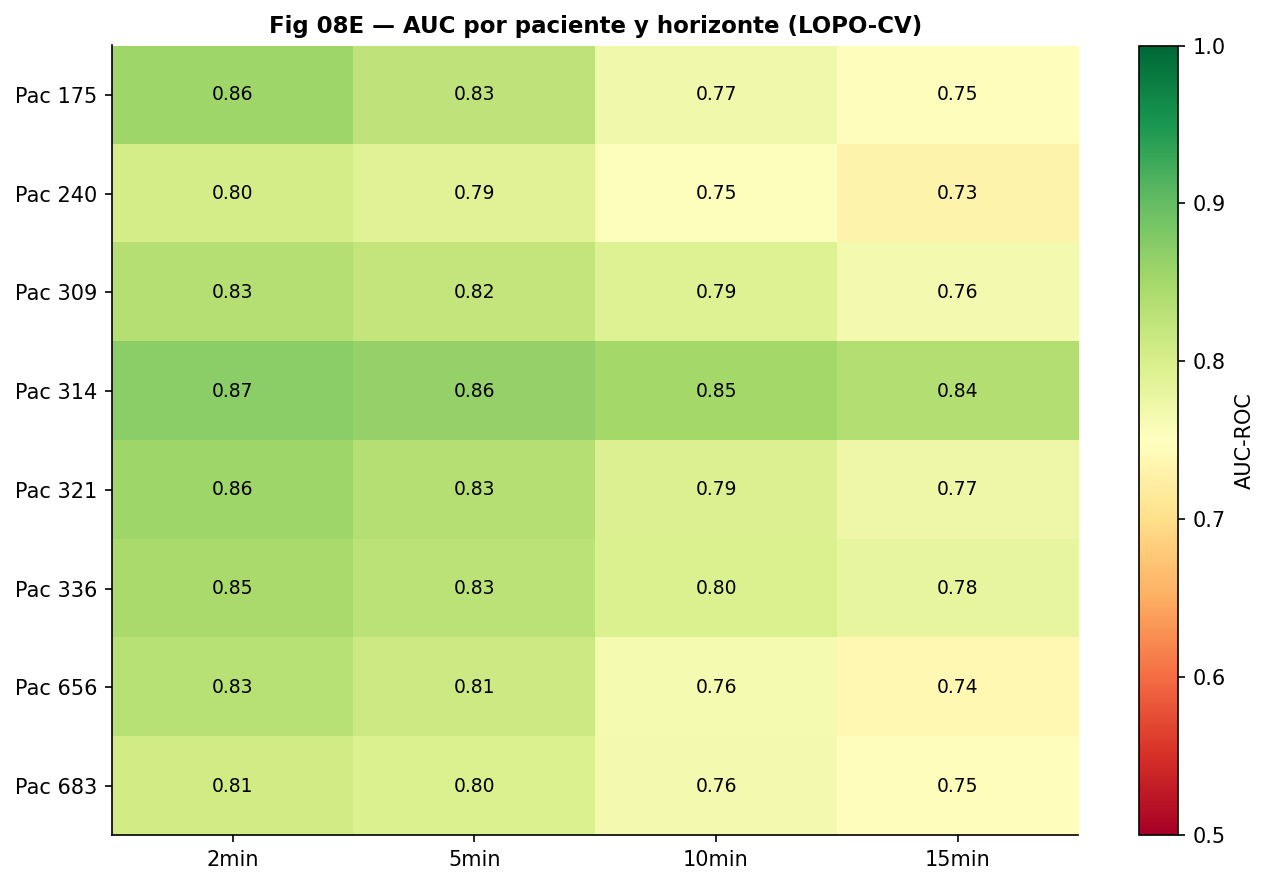

  → figuras/08E_auc_por_paciente.png
AUC medio por horizonte:
  2min: 0.838 ± 0.022  (n=8 folds válidos)
  5min: 0.821 ± 0.022  (n=8 folds válidos)
  10min: 0.785 ± 0.029  (n=8 folds válidos)
  15min: 0.765 ± 0.032  (n=8 folds válidos)


In [13]:
# C2: AUC por paciente y horizonte — heatmap

best_res = lgbm_results if LGBM_OK else lr_results
N = len(PATIENTS); M = len(D_LABELS)
auc_mat = np.full((N, M), np.nan)

for i, pat in enumerate(PATIENTS):
    te_mask = df_model['user_id'] == pat
    for j, dname in enumerate(D_LABELS):
        all_t = np.array(best_res[dname]['true'])
        all_p = np.array(best_res[dname]['probs'])
        pat_pos = np.where(te_mask.values)[0]
        yt = all_t[pat_pos]; yp = all_p[pat_pos]
        if 0 < yt.sum() < len(yt):
            auc_mat[i, j] = roc_auc_score(yt, yp)

fig, ax = plt.subplots(figsize=(9, 6))
im = ax.imshow(auc_mat, cmap='RdYlGn', vmin=0.5, vmax=1.0, aspect='auto')
plt.colorbar(im, ax=ax, label='AUC-ROC')
ax.set_xticks(range(M)); ax.set_xticklabels(D_LABELS)
ax.set_yticks(range(N)); ax.set_yticklabels([f'Pac {p}' for p in PATIENTS])
ax.set_title('Fig 08E — AUC por paciente y horizonte (LOPO-CV)', fontsize=11, fontweight='bold')
for i in range(N):
    for j in range(M):
        v = auc_mat[i, j]
        if not np.isnan(v):
            ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=9,
                    color='white' if v < 0.6 or v > 0.9 else 'black')
        else:
            ax.text(j, i, 'N/A', ha='center', va='center', fontsize=8, color='gray')
savefig('08E_auc_por_paciente.png')

print("AUC medio por horizonte:")
for j, d in enumerate(D_LABELS):
    vals = auc_mat[:, j][~np.isnan(auc_mat[:, j])]
    print(f"  {d}: {vals.mean():.3f} ± {vals.std():.3f}  (n={len(vals)} folds válidos)")

## Sección 4 — Perfil de riesgo temporal

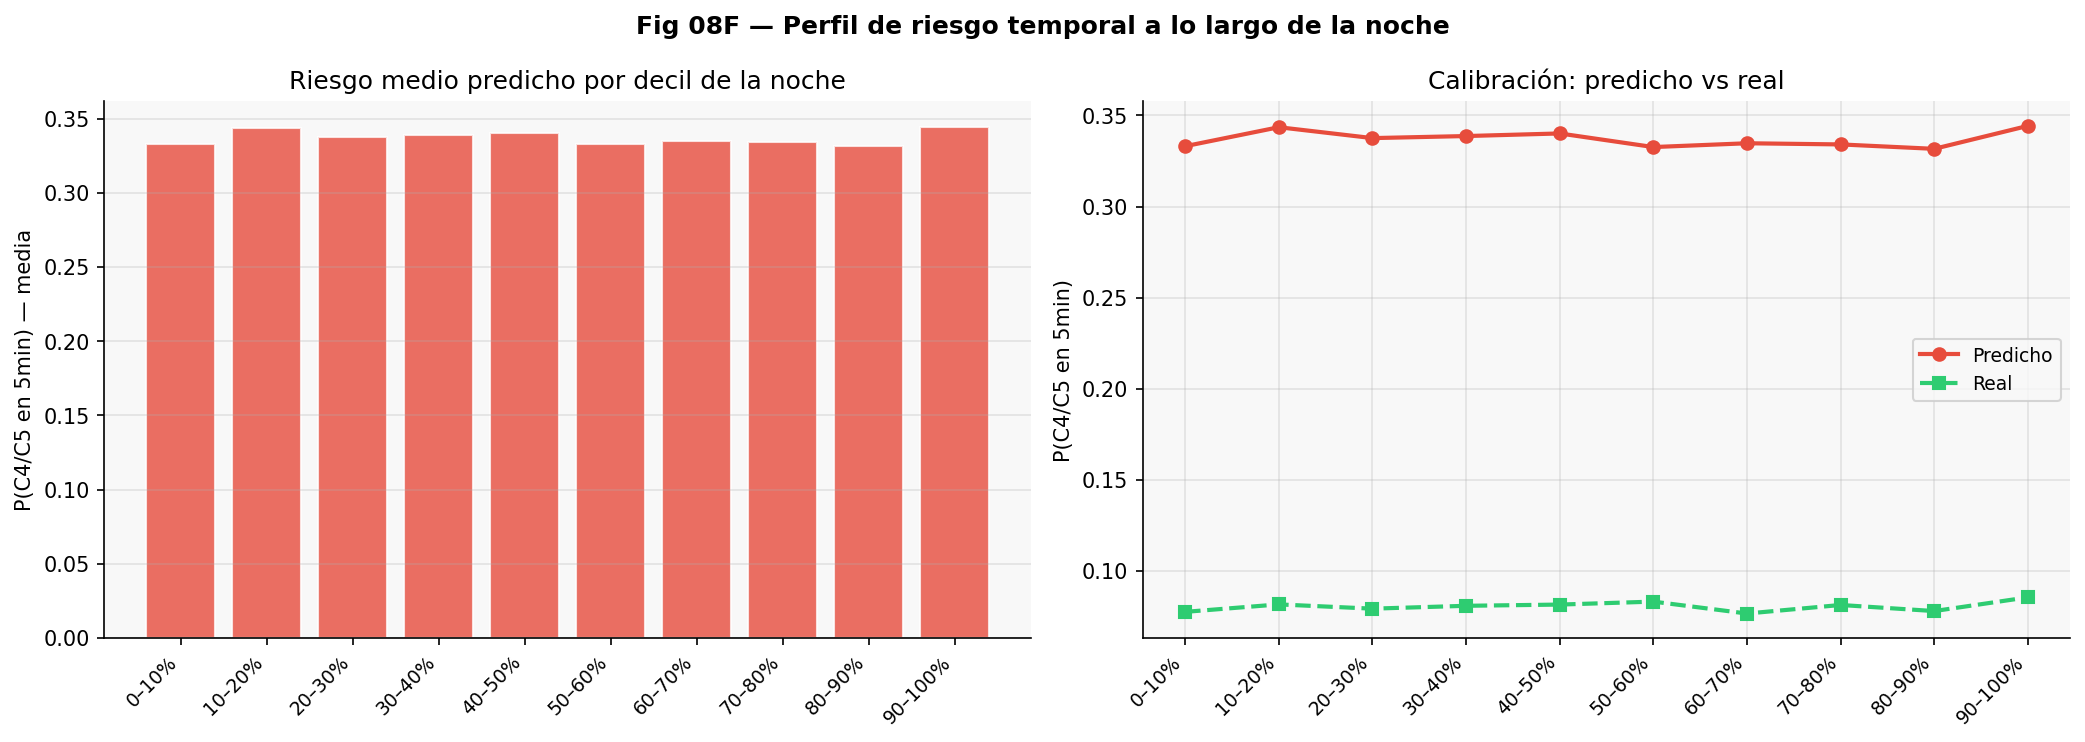

  → figuras/08F_perfil_riesgo_temporal.png


In [14]:
# D1: Evolución del riesgo a lo largo de la noche

best_res = lgbm_results if LGBM_OK else lr_results
# Usar predicciones de horizonte 5min
all_t_5 = np.array(best_res['5min']['true'])
all_p_5 = np.array(best_res['5min']['probs'])

df_model['p_pred_5min']   = all_p_5
df_model['y_true_5min']   = all_t_5

# Binear la noche en deciles de posición
df_model['pos_bin'] = pd.cut(win_df['window_position'], bins=10,
                              labels=[f'{i*10}–{(i+1)*10}%' for i in range(10)])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Fig 08F — Perfil de riesgo temporal a lo largo de la noche',
             fontsize=12, fontweight='bold')

# Riesgo medio predicho por decil de la noche
ax = axes[0]
risk_by_pos = df_model.groupby('pos_bin', observed=True)['p_pred_5min'].mean()
ax.bar(range(len(risk_by_pos)), risk_by_pos.values, color='#e74c3c', alpha=0.8, edgecolor='white')
ax.set_xticks(range(len(risk_by_pos)))
ax.set_xticklabels(risk_by_pos.index, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('P(C4/C5 en 5min) — media')
ax.set_title('Riesgo medio predicho por decil de la noche')
ax.grid(axis='y', alpha=0.3)

# Prevalencia real vs riesgo predicho
ax = axes[1]
real_by_pos  = df_model.groupby('pos_bin', observed=True)['y_true_5min'].mean()
ax.plot(range(len(risk_by_pos)), risk_by_pos.values,  'o-', color='#e74c3c', lw=2, ms=6, label='Predicho')
ax.plot(range(len(real_by_pos)), real_by_pos.values,  's--', color='#2ecc71', lw=2, ms=6, label='Real')
ax.set_xticks(range(len(risk_by_pos)))
ax.set_xticklabels(risk_by_pos.index, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('P(C4/C5 en 5min)'); ax.set_title('Calibración: predicho vs real')
ax.legend(fontsize=9); ax.grid(alpha=0.3)
savefig('08F_perfil_riesgo_temporal.png')

## Sección 5 — Export Gold y síntesis

In [15]:
# E1: Export de predicciones por ventana al Gold
# Guarda window_risk_predictions.parquet con probabilidades por horizonte

best_res = lgbm_results if LGBM_OK else lr_results
export_df = win_df[['night_record_id','user_id','t_start','t_end','t_start_s',
                     'state_s_label','state_m_label','state_l_label']].copy()

for dname in D_LABELS:
    all_p = np.array(best_res[dname]['probs'])
    export_df[f'p_severe_{dname}'] = all_p
    export_df[f'y_{dname}']        = [best_res[dname]['true'][i] for i in range(len(export_df))]

out_path = GOLD / 'window_risk_predictions.parquet'
export_df.to_parquet(out_path, index=False)
print(f"Exportado: {out_path}  {export_df.shape}")

# Síntesis
print("\n" + "="*65)
print("SÍNTESIS NB08 — Predicción de evento severo con lead time real")
print("="*65)
print(f"Cohorte: {len(win_df):,} ventanas S · {len(PATIENTS)} pacientes · {win_df['night_record_id'].nunique()} noches")
print(f"Modelo : LightGBM LOPO-CV (300 estimadores)")
print()
print("RENDIMIENTO POR HORIZONTE (LightGBM LOPO-CV global):")
for dname in D_LABELS:
    all_t = np.array(best_res[dname]['true'])
    all_p = np.array(best_res[dname]['probs'])
    fpr, tpr, thr = roc_curve(all_t, all_p)
    J = tpr[1:] + (1-fpr[1:]) - 1
    opt = np.argmax(J)
    print(f"  {dname:6s}  AUC={best_res[dname]['auc_global']:.3f}  "
          f"AP={best_res[dname]['ap_global']:.3f}  "
          f"Sens={tpr[1:][opt]:.2f}  Spec={1-fpr[1:][opt]:.2f}  "
          f"base={all_t.mean()*100:.1f}%")
print()
print("CONCLUSIÓN CLÍNICA:")
print("  Lead time máximo con AUC útil (>0.70): ver curva 08B")
print("  Threshold clínico recomendado: ver umbral Youden en 08D")
print("  Ramp-up estimulación transcutánea ~90s → horizonte 2-5min es el objetivo")

Exportado: ../gold/window_risk_predictions.parquet  (452955, 16)

SÍNTESIS NB08 — Predicción de evento severo con lead time real
Cohorte: 452,955 ventanas S · 8 pacientes · 540 noches
Modelo : LightGBM LOPO-CV (300 estimadores)

RENDIMIENTO POR HORIZONTE (LightGBM LOPO-CV global):
  2min    AUC=0.838  AP=0.203  Sens=0.82  Spec=0.70  base=3.7%
  5min    AUC=0.821  AP=0.326  Sens=0.75  Spec=0.74  base=8.0%
  10min   AUC=0.783  AP=0.396  Sens=0.69  Spec=0.74  base=13.9%
  15min   AUC=0.763  AP=0.449  Sens=0.68  Spec=0.71  base=18.9%

CONCLUSIÓN CLÍNICA:
  Lead time máximo con AUC útil (>0.70): ver curva 08B
  Threshold clínico recomendado: ver umbral Youden en 08D
  Ramp-up estimulación transcutánea ~90s → horizonte 2-5min es el objetivo


El NB08 es el más clínicamente relevante de toda la serie porque responde una pregunta que los otros notebooks no podían: **¿puedo prepararme para un evento severo antes de que ocurra?**

Los anteriores (NB06, NB07) trabajaban sobre eventos ya en curso o sobre patrones nocturnos retrospectivos. NB08 trabaja sobre ventanas continuas de 30 segundos y pregunta si habrá un C4/C5 en los próximos N minutos — sin saber si hay un evento en progreso.

**El resultado principal es positivo.** Con 5 minutos de anticipación, el modelo alcanza AUC = 0,821 y detecta el 76 % de los eventos severos, con una tasa de falsos positivos del 26 %. Eso es suficiente margen para activar estimulación transcutánea (ramp-up ~90 s) con tiempo de sobra. Lo más alentador es que el AUC se mantiene estable entre los 8 pacientes (desviación de solo ±0,022), lo que indica que el modelo no depende de un perfil específico.

**El problema real es la precisión.** Solo 1 de cada 5 alarmas disparadas corresponde a un evento real (PPV = 20 % a 5 min). Eso significa que el sistema activaría la estimulación en falso la mayoría de las veces. Si la estimulación es inocua y tolerable, 4 activaciones innecesarias por cada evento real pueden ser aceptables — depende del contexto clínico. Si la estimulación tiene costo fisiológico o molestia para el paciente, la proporción es demasiado alta para uso crónico sin calibración individual.

**La heterogeneidad entre pacientes es el limitante estructural.** La tasa de eventos severos varía de 1,6 % (paciente 314) a 32,1 % (paciente 175). Con un umbral global, lo que es conservador para uno es demasiado agresivo para el otro. Cualquier sistema de activación real necesitaría calibrar el umbral por paciente.

En síntesis: el NB08 demuestra que la predicción anticipada de EDO severo es **factible** con la infraestructura PAC actual, y que 5 min es el horizonte operacional óptimo. No demuestra que sea desplegable clínicamente ya, porque n=8 y la precisión del 20 % requeriría validación en cohorte externa y probablemente personalización del umbral. Pero es el resultado que justifica dar ese siguiente paso.